## Traverse field Ising model to demo primitives

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import YGate,UnitaryGate
import numpy as np

SYGate =UnitaryGate(YGate().power(1/2), label=r'$\sqrt{Y}$')
SYdgGate =UnitaryGate(SYGate.inverse() , label=r'$\sqrt{Y}^\dag$')

In [4]:
def generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits, trotter_barrier=False, layer_barrier=False):
    
    if num_cl_bits == 0:
        qc = QuantumCircuit(num_qubits)
    else:
        qc = QuantumCircuit(num_qubits , num_cl_bits)

    for trotter_step in range(num_trotter_steps):
        add_id_tfim_trotter_layer(qc,rx_angle, layer_barrier)
        if trotter_barrier:
            qc.barrier()

    return qc
    
def add_id_tfim_trotter_layer(qc, rx_angle, layer_barrier = False):
     #Adding Rzz in even layers
     for i in range(0, qc.num_qubits - 1, 2):  
         qc.sdg([i, i + 1])
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
     if layer_barrier:
         qc.barrier()
     #Adding Rzz in odd layers
     for i in range(1, qc.num_qubits - 1, 2):  
         qc.sdg([i, i + 1])
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
     if layer_barrier:
         qc.barrier()
     qc.rx(rx_angle, list(range(qc.num_qubits)))
     if layer_barrier:
        qc.barrier()

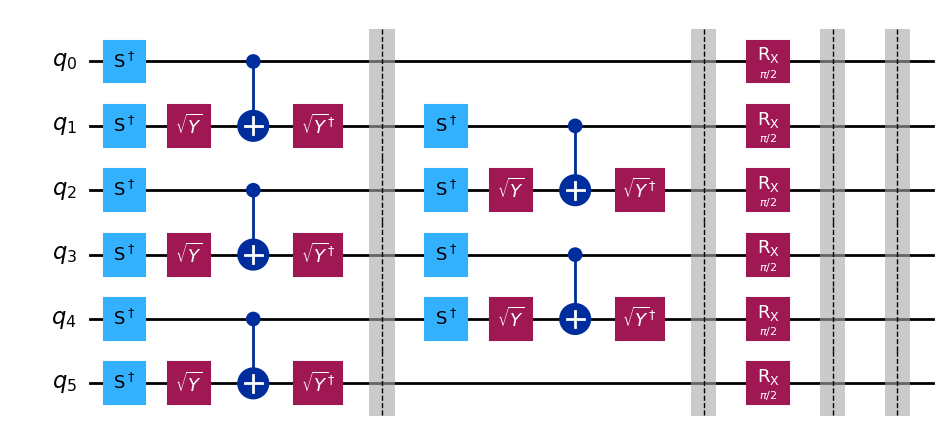

In [5]:
num_qubits = 6
num_trotter_steps = 1
rx_angle = 0.5 * np.pi

qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=0, trotter_barrier=True, layer_barrier=True)
qc.draw('mpl', fold=-1)

## Demo Sampler

In [6]:
def append_mirrored_1d_tfim_circuit(qc,num_qubits, num_trotter_steps, rx_angle, trotter_barrier=False, layer_barrier=False):

    for trotter_step in range(num_trotter_steps):
        add_mirrored_id_tfim_trotter_layer(qc,rx_angle, layer_barrier)
        if trotter_barrier:
            qc.barrier()

    return qc
    
def add_mirrored_id_tfim_trotter_layer(qc, rx_angle, layer_barrier = False):
     qc.rx(-rx_angle, list(range(qc.num_qubits)))
     if layer_barrier:
        qc.barrier()
     #Adding Rzz in odd layers
     for i in range(1, qc.num_qubits - 1, 2):  
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
         qc.s([i, i + 1]) 
     if layer_barrier:
         qc.barrier()   
     #Adding Rzz in even layers
     for i in range(0, qc.num_qubits - 1, 2):  
         qc.append(SYGate, [i+1])
         qc.cx(i, i + 1)
         qc.append(SYdgGate, [i + 1])
         qc.s([i, i + 1])
     if layer_barrier:
         qc.barrier()

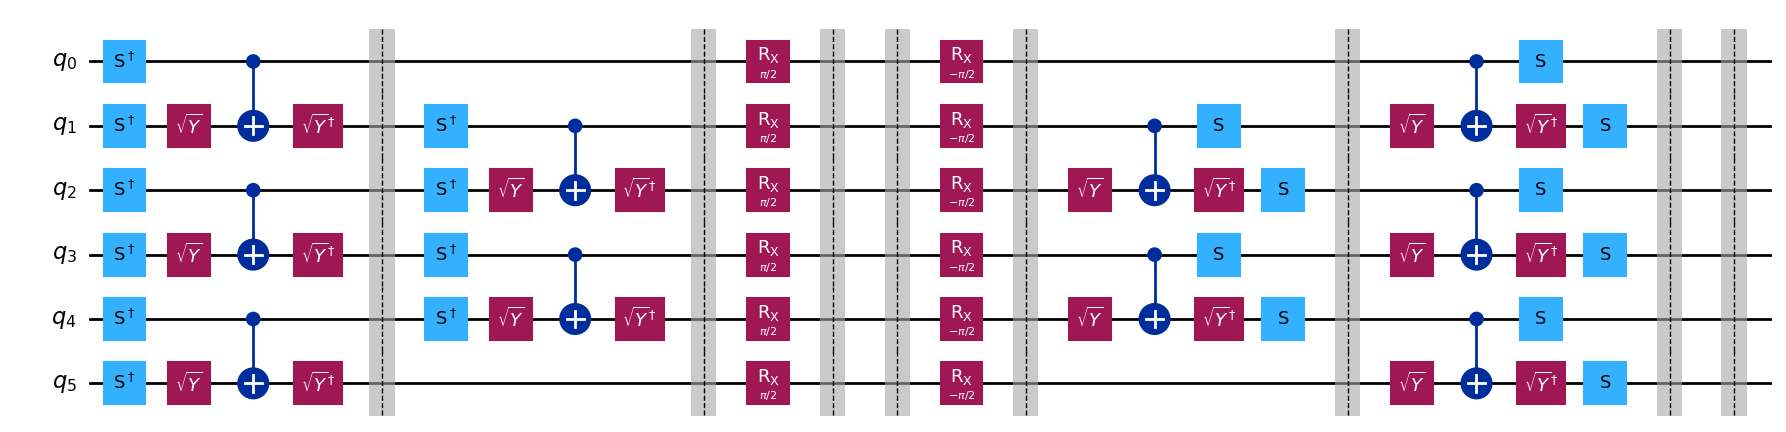

In [7]:
append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barrier=True)
qc.draw('mpl', fold=-1)

#### Step 1: Map the problems to circuit and observables

In [8]:
max_trotter_steps = 10
num_qubits = 100
measured_qubits = [49,50]

qc_list = []
for trotter_step in range(max_trotter_steps):
    qc = generate_1d_tfim_circuit(num_qubits, num_trotter_steps, rx_angle, num_cl_bits=len(measured_qubits), trotter_barrier=True, layer_barrier=True)
    append_mirrored_1d_tfim_circuit(qc, num_qubits, num_trotter_steps, rx_angle, trotter_barrier=True, layer_barrier=True)
    qc.measure(measured_qubits, list(range(len(measured_qubits))))
    qc_list.append(qc)


#### Step 2: Optimize

In [9]:
from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend_name = 'ibm_brisbane'
service = QiskitRuntimeService()
backend = service.backend(backend_name)
print("Done getting backend")

qc_transpiled_list = transpile(qc_list, backend=backend, optimization_level=1)

management.get:WARNING:2025-10-16 06:19:19,865: Loading default saved account


Done getting backend


#### Step 3: Execute on hardware

In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = 'XY4'

job = sampler.run(qc_transpiled_list)

print(job.job_id())  # Print the job ID to track the 

d3o8ssbnquss73e48am0


#### Post processing and plotting

In [12]:
job_id = "d3o8ssbnquss73e48am0"
job = service.job(job_id)

survival_probability_list = []

for trotter_step in range(max_trotter_steps):
    try:
        data = job.result()[trotter_step].data
        survival_probability_list.append(data.c.get_counts()['0' *  len(measured_qubits)] / data.c.num_shots)
    except:
        survival_probability_list.append(0)

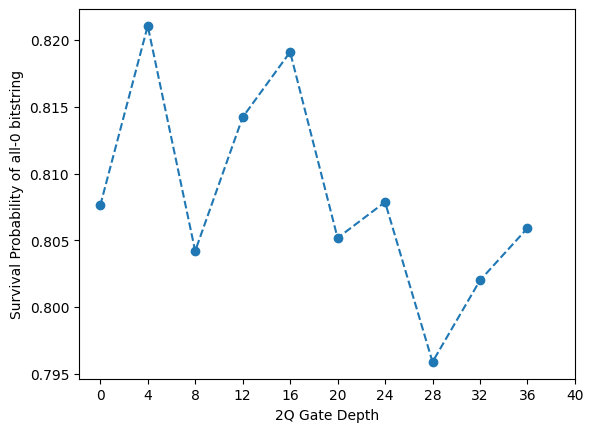

In [14]:
import matplotlib.pyplot as plt

plt.plot(list(range(0,4 * max_trotter_steps, 4)), survival_probability_list, '--o')
plt.xlabel('2Q Gate Depth')
plt.ylabel('Survival Probability of all-0 bitstring')
plt.xticks(np.arange(0,44,4))
plt.show()